# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

# Google Play App Reviews — Text Data Visualizations

This notebook analyzes the `GooglePlay_App_Data.csv` dataset and creates **three visualizations from text data** based on user reviews from the Google Play Store.  
The goal is to highlight common themes in the review text, identify complaint patterns in low-rated reviews, and compare review length across star ratings.


# Dataset Overview

This dataset contains user-generated reviews collected from applications on the Google Play Store. It includes review text, ratings, engagement metrics, user information, review dates, and developer responses. The dataset is useful for sentiment analysis, customer feedback mining, app quality assessment, and understanding user satisfaction and engagement trends.

**Dataset:** `GooglePlay_App_Data.csv`  
**Source:** Kaggle


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import CountVectorizer

# Load dataset
df = pd.read_csv("GooglePlay_App_Data.csv")

# Basic cleanup
df["review_description"] = df["review_description"].fillna("").astype(str)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Create a cleaned text column
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review_description"].apply(clean_text)

# Review length feature
df["review_word_count"] = df["clean_review"].str.split().str.len()

print("Dataset shape:", df.shape)
print(df[["review_description", "rating", "thumbs_up"]].head())


Dataset shape: (161, 14)
                                  review_description  rating  thumbs_up
0                        Still loving it!, the best!       5          0
1  Convenient one stop app for all your passwords...       5          0
2  Tried several password managers until I came a...       5          0
3                                       Ok thank you       5          0
4  switched phones and none of my passwords came ...       1          0


## 1) Most Frequent Words in All Reviews

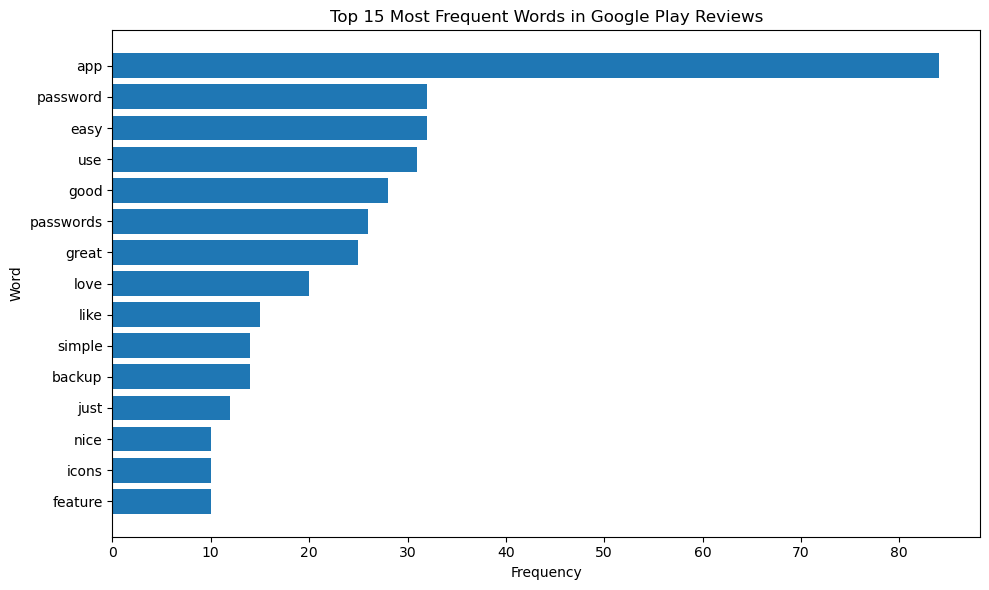

,word,count
0,app,84
2,easy,32
11,password,32
14,use,31
4,good,28
12,passwords,26
5,great,25
9,love,20
8,like,15
1,backup,14


In [6]:
# Visualization 1: Most frequent words across all reviews
vectorizer = CountVectorizer(stop_words="english", max_features=15)
X = vectorizer.fit_transform(df["clean_review"])
word_counts = np.asarray(X.sum(axis=0)).ravel()
words = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({"word": words, "count": word_counts}).sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(freq_df["word"], freq_df["count"])
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 15 Most Frequent Words in Google Play Reviews")
plt.tight_layout()
plt.show()

freq_df.sort_values("count", ascending=False)


**Explanation:** This figure shows the most common individual words used across all review descriptions after removing English stop words.  
The chart helps identify the dominant conversation topics in the dataset; for example, frequent words related to usability, performance, or account access can quickly reveal what users mention most often.

## 2) Most Frequent Bigrams in Low-Rated Reviews (1–2 Stars)

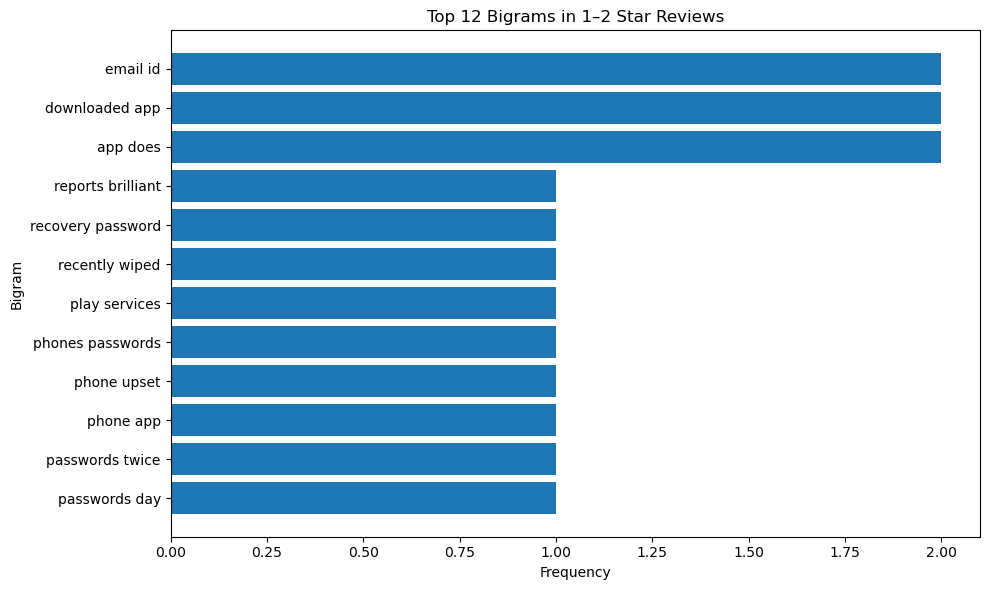

,bigram,count
0,app does,2
1,downloaded app,2
2,email id,2
3,passwords day,1
4,passwords twice,1
5,phone app,1
6,phone upset,1
7,phones passwords,1
8,play services,1
9,recently wiped,1


In [7]:
# Visualization 2: Complaint themes in low-rated reviews
low_rated = df[df["rating"] <= 2].copy()

bigram_vectorizer = CountVectorizer(stop_words="english", ngram_range=(2, 2), max_features=12)
X_low = bigram_vectorizer.fit_transform(low_rated["clean_review"])
bigram_counts = np.asarray(X_low.sum(axis=0)).ravel()
bigrams = bigram_vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({"bigram": bigrams, "count": bigram_counts}).sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(bigram_df["bigram"], bigram_df["count"])
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 12 Bigrams in 1–2 Star Reviews")
plt.tight_layout()
plt.show()

bigram_df.sort_values("count", ascending=False)


**Explanation:** This figure focuses only on 1–2 star reviews and highlights the most common two-word phrases.  
These bigrams are useful for spotting repeated complaint themes, which can help explain why users leave poor ratings and show where the app experience may be breaking down.

## 3) Review Length by Star Rating

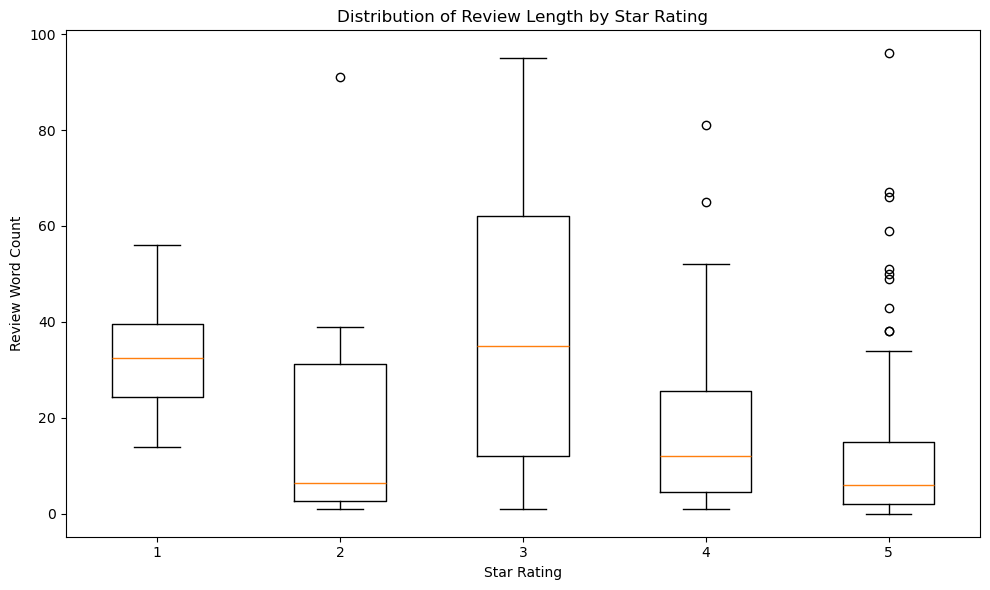

,mean,median,count
rating,,,
1,32.750000,32.5,8
2,24.333333,6.5,6
3,42.111111,35.0,9
4,18.961538,12.0,26
5,12.491071,6.0,112


In [8]:
# Visualization 3: Review length by rating
length_by_rating = [df.loc[df["rating"] == r, "review_word_count"] for r in sorted(df["rating"].dropna().unique())]

plt.figure(figsize=(10, 6))
plt.boxplot(length_by_rating, tick_labels=[str(int(r)) for r in sorted(df["rating"].dropna().unique())])
plt.xlabel("Star Rating")
plt.ylabel("Review Word Count")
plt.title("Distribution of Review Length by Star Rating")
plt.tight_layout()
plt.show()

df.groupby("rating")["review_word_count"].agg(["mean", "median", "count"]).sort_index()


**Explanation:** This boxplot compares how long reviews are for each star rating by counting the number of words in each review.  
It helps show whether dissatisfied users tend to leave longer, more detailed feedback than satisfied users, which can reveal how strongly people feel when they report problems or praise the app.